# Use earthkit-transforms to calculate temporal statistics

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt

## Load test data

In this example we will use hourly ERA5 point data from the
[ERA5 single levels time-series](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries)
collection in the Climate Data Store.

The code cell below uses `earthkit-data` to download the data from the CDS, and then open it as an `xarray.Dataset` object.
We have chosen the 2 metre air temperature for the point 51.5˚ N, -1.0˚ E  for the years 1940 to 2025, but this is
configurable in the following code cell.

In [2]:
dataset = "reanalysis-era5-single-levels-timeseries"
request = {
    "variable": "2m_temperature",
    "location": {"longitude": -1, "latitude": 51.5},
    "date": ["1940-01-01/2025-12-31"],
    "data_format": "netcdf"
}
era5_hourly_ekds = ekd.from_source("cds", dataset, request)
era5_hourly_ds = era5_hourly_ekds.to_xarray()
era5_hourly_ds


<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 3MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

# Climate Stripes

Earthkit transforms provides some easy to use methods for calculating complex computations,
and Earthkit plots provide some easy tools for visualising these methods.

The code cell below computes the annual anomaly for the point we have selected in one line!

Then we can plot the iconic climate stripes, also in a single line!

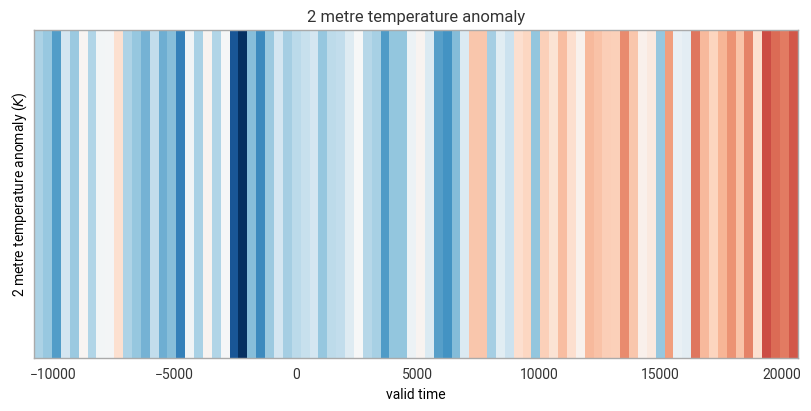

In [7]:
anomaly = ekt.climatology.auto_anomaly(era5_hourly_ds, frequency="year", climatology_range=("1981", "2010"))
chart = ekp.timeseries.stripes(anomaly, cmap="RdBu_r")

The above example demonstrated how simple it is to create effective output with the
Earthkit tools. However, this is a highly specific and specialised example.
Below we demonstrate that it's possible to create more general data products
and visaulisations, all using simple and high-level tools.

# Calculate Daily and Monthly statistics

Earthkit transforms also provides easy to use tools for calculating temporal statistics.
No more do you need to worry about the differences in data standards,
`earthkit-transforms` will detect the temporal dimensions and apply the statistics appropriately.

The code cells below calculate various statistics as single line computations. As demonstrated by the
daily calculations in the first cell, the `earthkit-transforms` methods accept raw earthkit
objects and the xarray objects as input.

In [8]:
# Calculate daily mean with raw earthkit-data object:
daily_mean = ekt.temporal.daily_mean(era5_hourly_ekds)

# Calulate daily mininum and maximum temperature with the xarray object:
daily_minimum = ekt.temporal.daily_min(era5_hourly_ds)
daily_maximum = ekt.temporal.daily_max(era5_hourly_ds)

# Calculate monthly mean with the xarray object:
monthly_mean = ekt.temporal.monthly_mean(era5_hourly_ds)

# Calculate monthly 10th and 90th percentiles with the xarray object.
# These are not (yet) directly accessible methods, but the generalised monthly_reduce method
# can be used to calculate any quantile:
monthly_10th = ekt.temporal.monthly_reduce(era5_hourly_ds, how="quantile", q=0.1)
monthly_90th = ekt.temporal.monthly_reduce(era5_hourly_ds, how="quantile", q=0.9)


## Calculate the monthly and daily climatologies

The climatology module offers a range of methods for calculating climatological statistics,
for example monthly and daily climatologies for a specified climatology period.

In the example below, we calculate the monthly mean, the monthly 10th and 90th percentiles,
the daily mean, the daily maximum, and the daily minimum
for our 2m temperature data for the `climatology_range` 1990 to 2020.

In the returned objects the valid_time dimension has been replaced with a
`month` or `dayofyear` dimension with values 1 to 12 and 1 to 366, respectively.


In [9]:
climatology_period = ("1981", "2010")

climatology_monthly_mean = ekt.climatology.monthly_mean(era5_hourly_ds, climatology_range=climatology_period)
climatology_monthly_quantiles = ekt.climatology.quantiles(
    era5_hourly_ds, [0.1, 0.9], frequency="month", climatology_range=climatology_period
)

climatology_daily_mean = ekt.climatology.daily_mean(era5_hourly_ds, climatology_range=climatology_period)
climatology_daily_max = ekt.climatology.daily_max(era5_hourly_ds, climatology_range=climatology_period)
climatology_daily_min = ekt.climatology.daily_min(era5_hourly_ds, climatology_range=climatology_period)

climatology_monthly_mean

<xarray.Dataset> Size: 208B
Dimensions:    (month: 12)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    latitude   float64 8B 51.5
    longitude  float64 8B -1.0
Data variables:
    t2m        (month) float64 96B 277.8 277.6 279.7 281.7 ... 284.0 280.4 278.0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Plot the data on a time-series

Now we add the climatology to the background of the Timeseries plot for the daily mean on the original `valid_time` dimension.
First we create the repeated climatology for the monthly quantiles, then we plot with `earthkit-plots`.

In the first example we choose a subset of the time-series so we the various products we calculated.

/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-training/2026-eumetnet-ai-workshop-earthkit/.venv/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:262: UserWarning: No key "latitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')
/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-training/2026-eumetnet-ai-workshop-earthkit/.venv/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:262: UserWarning: No key "longitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')


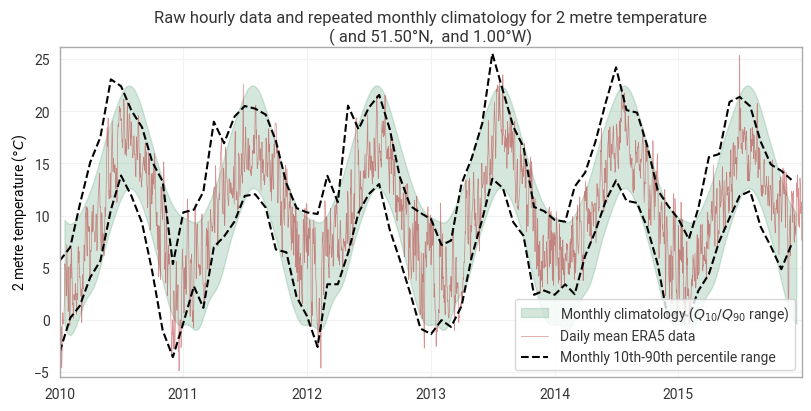

In [24]:
plot_period = ("2010", "2015")

chart = ekp.TimeSeries()

# repeat_years tiles the month-dimensioned climatology across 2015–2017
# automatically — no dummy datetime coordinates needed.
chart.fill_between(
    climatology_monthly_quantiles.sel(quantile=0.1),
    climatology_monthly_quantiles.sel(quantile=0.9),
    units="celsius",
    label="Monthly climatology ($Q_{10} / Q_{90}$ range)",
    color="seagreen",
    drawstyle="spline",
    repeat_years=range(int(plot_period[0]), int(plot_period[1])+1),
)

chart.line(
    daily_mean.sel(valid_time=slice(*plot_period)),
    units="celsius",
    label="Daily mean ERA5 data",
    color="firebrick",
    lw=0.5, alpha=0.5
)

chart.line(
    monthly_10th.sel(valid_time=slice(*plot_period)),
    units="celsius",
    label="Monthly 10th-90th percentile range",
    linestyle="--",
    color="black",
)
chart.line(monthly_90th.sel(valid_time=slice(*plot_period)), units="celsius", linestyle="--", color="black")

chart.title(
    "Raw hourly data and repeated monthly climatology for {variable_name}\n"
    "({latitude:%Lt}, {longitude:%Ln})"
)

chart.ylabel()
chart.legend()
chart.show()

The next example, we plot the entire time series, but only for the monthly and daily means to not over-crowd the plot.

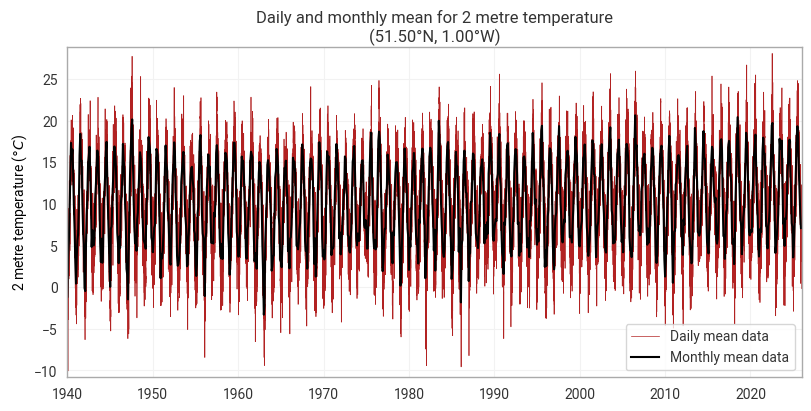

In [ ]:
chart = ekp.TimeSeries()

chart.line(
    daily_mean,
    units="celsius",
    label="Daily mean data",
    color="firebrick",
    lw=0.5,
)
chart.line(
    monthly_mean,
    units="celsius",
    label="Monthly mean data",
    color="black",
)
chart.title(
    "Daily and monthly mean for {variable_name}\n"
    "({latitude:%Lt}, {longitude:%Ln})"
)

chart.ylabel()
chart.legend()
chart.show()